# House Price Prediction Project

## 1. Problem Statement
This project focuses on predicting house sale prices using property features such as city, house type, area, number of bedrooms, and listing duration.

The dataset required extensive data cleaning and preprocessing, including:
- handling missing values
- correcting inconsistent categorical values
- converting data types
- feature engineering

After cleaning the data, machine learning models were developed to predict house prices and evaluate model performance.

The goal of this project is to demonstrate practical data cleaning, exploratory analysis, feature engineering, and predictive modeling skills using Python and scikit-learn.

In [74]:
## 2. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [75]:
## 3. Load Dataset

df = pd.read_csv(r"C:\Users\USER\Desktop\house-price-prediction\data\house_sales.csv")

df.head()

# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1500, 8)

Columns:
Index(['house_id', 'city', 'sale_price', 'sale_date', 'months_listed',
       'bedrooms', 'house_type', 'area'],
      dtype='object')

Data Types:
house_id           int64
city              object
sale_price         int64
sale_date         object
months_listed    float64
bedrooms           int64
house_type        object
area              object
dtype: object

Missing Values:
house_id          0
city              0
sale_price        0
sale_date         0
months_listed    31
bedrooms          0
house_type        0
area              0
dtype: int64


## Initial Observations

Key observations from the raw dataset:
- Some columns contain missing values.
- Certain columns require datatype conversion.
- Categorical columns contain inconsistent text formatting.
- Numeric columns require cleaning and standardization.
- The dataset requires preprocessing before machine learning modeling.

## Data Cleaning

During exploration of the dataset, several data quality issues were identified:

### Observed Issues
- Missing city values were represented using `"--"` instead of standard null values.
- The `area` column contained numeric values stored as text with the suffix `"sq.m."`.
- The `house_type` column contained abbreviated category names such as:
  - `Det.`
  - `Semi`
  - `Terr.`
- Some numeric columns contained invalid or missing values.
- The `sale_date` column contained missing dates.

To prepare the dataset for machine learning, the following preprocessing steps were performed:
- standardized categorical values
- converted text-based numeric columns into numeric format
- handled missing values
- corrected inconsistent category labels
- converted date columns into datetime format

In [76]:
# Creating a working copy
clean_data = df.copy()

In [77]:
# Clean city column

# Replacing '--' with Unknown
clean_data['city'] = clean_data['city'].replace('--', 'Unknown')

# Remove extra spaces
clean_data['city'] = clean_data['city'].str.strip()

# Check cleaned categories
clean_data['city'].value_counts()

city
Silvertown    517
Teasdale      366
Poppleton     362
Riverford     182
Unknown        73
Name: count, dtype: int64

In [78]:
# Clean house_type column

# Standardize abbreviations
clean_data['house_type'] = clean_data['house_type'].replace({
    'Det.': 'Detached',
    'Semi': 'Semi-detached',
    'Terr.': 'Terraced'
})

# Fill missing values with mode
house_mode = clean_data['house_type'].mode()[0]

clean_data['house_type'] = clean_data['house_type'].fillna(house_mode)

# Check cleaned categories
clean_data['house_type'].value_counts()

house_type
Detached         1124
Semi-detached     245
Terraced          131
Name: count, dtype: int64

In [79]:

# Clean area column


# Remove 'sq.m.' text
clean_data['area'] = (
    clean_data['area']
    .str.replace(' sq.m.', '', regex=False)
)

# Convert to numeric
clean_data['area'] = pd.to_numeric(
    clean_data['area'],
    errors='coerce'
)

# Fill missing values
area_mean = round(clean_data['area'].mean(), 1)

clean_data['area'] = clean_data['area'].fillna(area_mean)

# Round values
clean_data['area'] = clean_data['area'].round(1)

# Preview
clean_data['area'].head()

0    107.8
1    498.8
2    542.5
3    528.4
4    477.1
Name: area, dtype: float64

In [80]:

# Clean bedrooms column

clean_data['bedrooms'] = pd.to_numeric(
    clean_data['bedrooms'],
    errors='coerce'
)

bedroom_mean = round(clean_data['bedrooms'].mean())

clean_data['bedrooms'] = clean_data['bedrooms'].fillna(bedroom_mean)

clean_data['bedrooms'] = clean_data['bedrooms'].astype(int)

In [81]:
# Clean months_listed column

clean_data['months_listed'] = pd.to_numeric(
    clean_data['months_listed'],
    errors='coerce'
)

months_mean = round(
    clean_data['months_listed'].mean(),
    1
)

clean_data['months_listed'] = clean_data['months_listed'].fillna(months_mean)

clean_data['months_listed'] = clean_data['months_listed'].round(1)

In [82]:
# Clean sale_price column

clean_data['sale_price'] = pd.to_numeric(
    clean_data['sale_price'],
    errors='coerce'
)

# Remove missing values
clean_data = clean_data.dropna(subset=['sale_price'])

# Remove invalid values
clean_data = clean_data[
    clean_data['sale_price'] >= 0
]

In [83]:

# Clean sale_date column

clean_data['sale_date'] = clean_data['sale_date'].fillna('2023-01-01')

clean_data['sale_date'] = pd.to_datetime(
    clean_data['sale_date']
)

In [84]:
# Final validation

print(clean_data.info())

print("\nMissing Values:\n")
print(clean_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   house_id       1500 non-null   int64         
 1   city           1500 non-null   object        
 2   sale_price     1500 non-null   int64         
 3   sale_date      1500 non-null   datetime64[ns]
 4   months_listed  1500 non-null   float64       
 5   bedrooms       1500 non-null   int64         
 6   house_type     1500 non-null   object        
 7   area           1500 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 93.9+ KB
None

Missing Values:

house_id         0
city             0
sale_price       0
sale_date        0
months_listed    0
bedrooms         0
house_type       0
area             0
dtype: int64


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to better understand:
- price distributions
- relationships between variables
- category frequencies
- feature correlations
- potential predictive patterns

Visualization techniques were used to identify trends and support business insights.

In [85]:
# Plot settings
plt.figure(figsize=(8, 5))

sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

## Distribution of House Prices

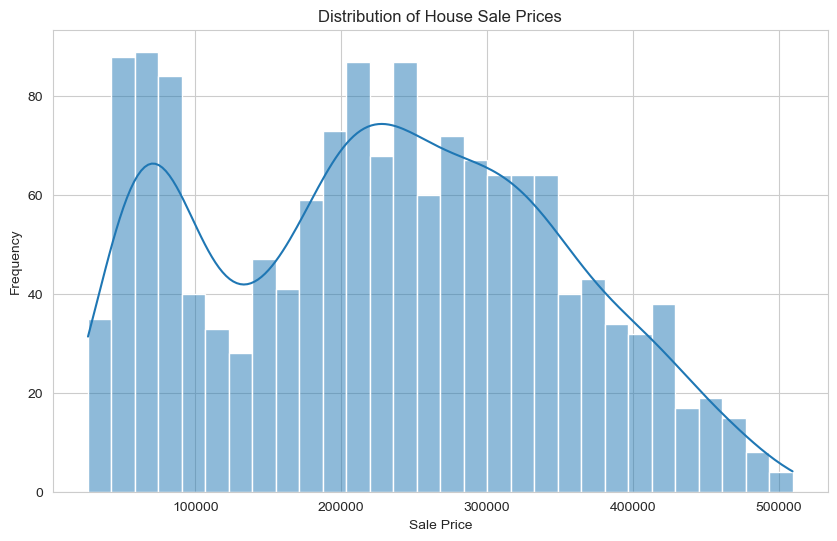

In [86]:
plt.figure(figsize=(10, 6))

sns.histplot(
    clean_data['sale_price'],
    bins=30,
    kde=True
)

plt.title("Distribution of House Sale Prices")

plt.xlabel("Sale Price")

plt.ylabel("Frequency")

plt.show()

### Observation

The distribution of house sale prices is moderately right-skewed and appears to contain multiple peaks, suggesting the presence of different housing market segments within the dataset. Higher-priced properties occur less frequently compared to mid-range properties.

## House Type Distribution

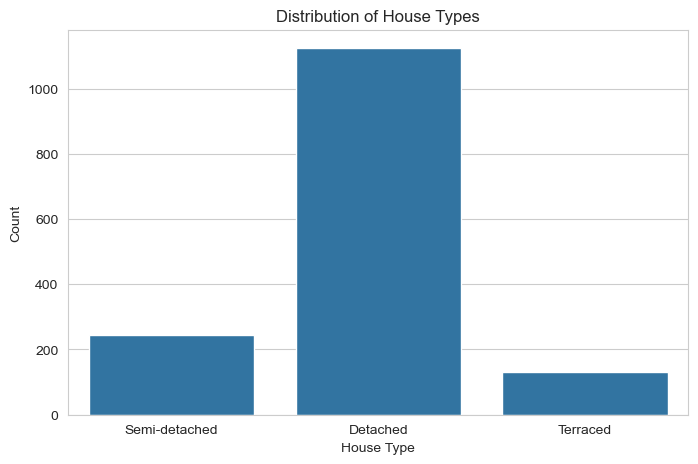

In [87]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_data,
    x='house_type'
)

plt.title("Distribution of House Types")

plt.xlabel("House Type")

plt.ylabel("Count")

plt.show()

### Observation

Detached house types appear more frequently in the dataset, which may influence prediction patterns and market behavior.

## City Distribution


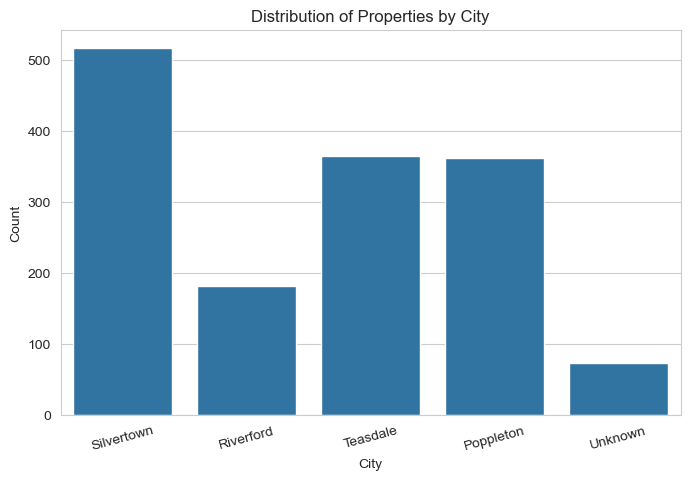

In [88]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_data,
    x='city'
)

plt.title("Distribution of Properties by City")

plt.xlabel("City")

plt.ylabel("Count")

plt.xticks(rotation=15)

plt.show()

## Relationship Between Area and Sale Price

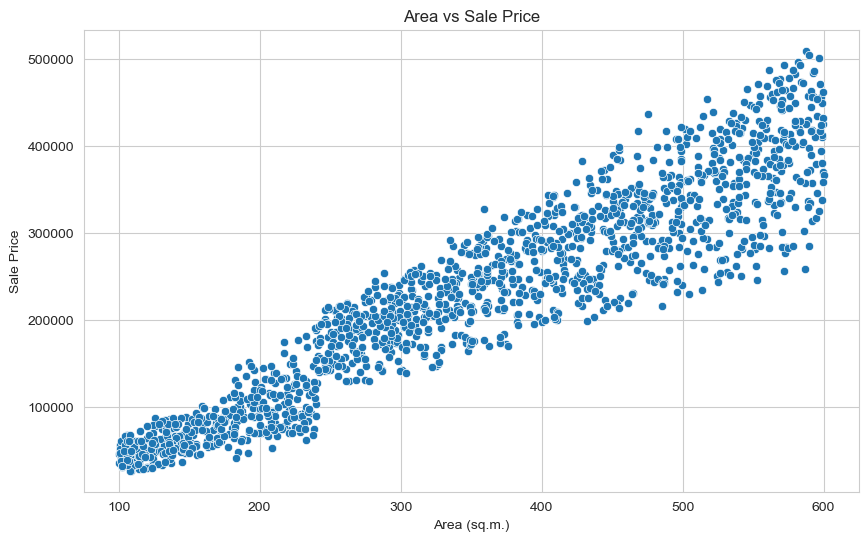

In [89]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_data,
    x='area',
    y='sale_price'
)

plt.title("Area vs Sale Price")

plt.xlabel("Area (sq.m.)")

plt.ylabel("Sale Price")

plt.show()

### Observation

There appears to be a positive relationship between property area and sale price, suggesting that larger properties generally command higher prices.

## Correlation Analysis

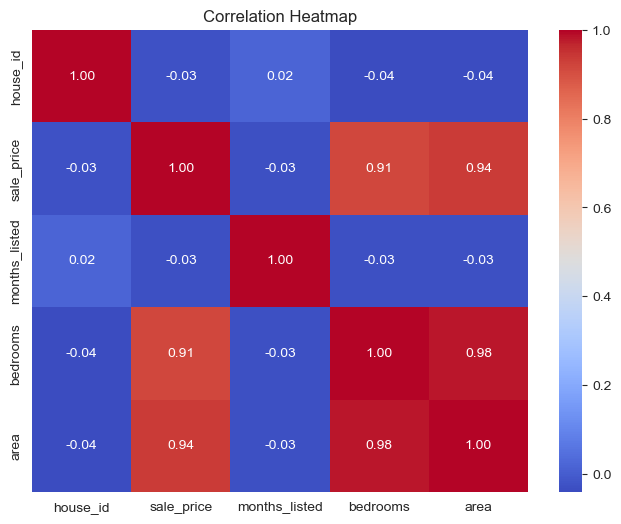

In [90]:
# Select numeric columns
numeric_cols = clean_data.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap reveals the strength and direction of relationships between numeric variables.

Features with stronger positive correlations to `sale_price` may be important predictors in the machine learning models.

## Sale Price by House Type

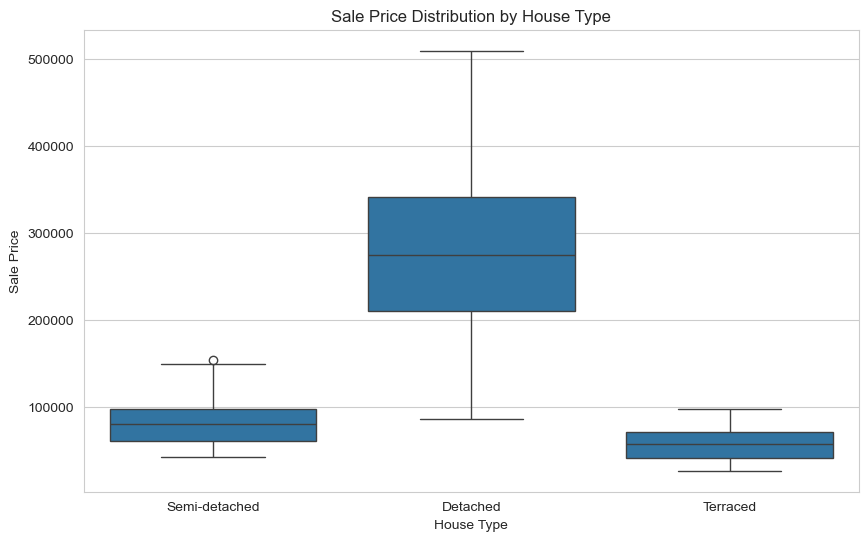

In [91]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clean_data,
    x='house_type',
    y='sale_price'
)

plt.title("Sale Price Distribution by House Type")

plt.xlabel("House Type")

plt.ylabel("Sale Price")

plt.show()

### Observation

Different house types exhibit varying sale price distributions. Some property categories tend to have higher median prices and greater variability in pricing.

## Months Listed Distribution

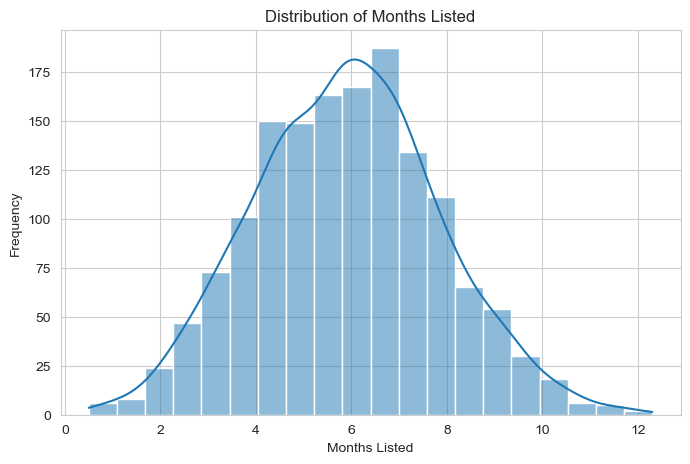

In [92]:
plt.figure(figsize=(8, 5))

sns.histplot(
    clean_data['months_listed'],
    bins=20,
    kde=True
)

plt.title("Distribution of Months Listed")

plt.xlabel("Months Listed")

plt.ylabel("Frequency")

plt.show()

### Observation

The distribution of `months_listed` appears approximately normal, indicating that most properties remain listed for durations close to the average listing period, with fewer extreme values on either side of the distribution.

# Feature Engineering

Before training machine learning models, categorical variables were transformed into numerical representations using one-hot encoding.

This ensures compatibility with machine learning algorithms while preserving categorical information.

In [93]:
# One-hot encode categorical variables

model_data = pd.get_dummies(
    clean_data,
    columns=['city', 'house_type'],
    drop_first=True
)

# Preview
model_data.head()

,house_id,sale_price,sale_date,months_listed,bedrooms,area,city_Riverford,city_Silvertown,city_Teasdale,city_Unknown,house_type_Semi-detached,house_type_Terraced
0,1217792,55943,2021-09-12,5.4,2,107.8,False,True,False,False,True,False
1,1900913,384677,2021-01-17,6.3,5,498.8,False,True,False,False,False,False
2,1174927,281707,2021-11-10,6.9,6,542.5,True,False,False,False,False,False
3,1773666,373251,2020-04-13,6.1,6,528.4,False,True,False,False,False,False
4,1258487,328885,2020-09-24,8.7,5,477.1,False,True,False,False,False,False


## Define Features and Target Variable

In [94]:
# Features
X = model_data.drop(columns=['sale_price', 'sale_date'])

# Target
y = model_data['sale_price']

print("Feature shape:", X.shape)

print("Target shape:", y.shape)

Feature shape: (1500, 10)
Target shape: (1500,)


## Train-Test Split

In [95]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)

print("Testing set:", X_test.shape)

Training set: (1200, 10)
Testing set: (300, 10)


# Baseline Model — Linear Regression

In [96]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predictions
lr_preds = lr_model.predict(X_test)

In [97]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# Metrics
lr_mae = mean_absolute_error(y_test, lr_preds)

lr_mse = mean_squared_error(y_test, lr_preds)

# RMSE
lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Performance")

print(f"MAE: {lr_mae:.2f}")

print(f"RMSE: {lr_rmse:.2f}")

print(f"R² Score: {lr_r2:.4f}")

Linear Regression Performance
MAE: 16775.85
RMSE: 22110.57
R² Score: 0.9629


### Model Performance Interpretation

The Linear Regression model demonstrated strong predictive performance on the housing dataset.

- The Mean Absolute Error (MAE) of approximately 16,776 indicates that, on average, predicted house prices differ from actual prices by about \$16.8k.
- The Root Mean Squared Error (RMSE) of approximately 22,111 suggests relatively low prediction error overall, while accounting for larger deviations.
- The R² score of 0.9629 indicates that the model explains approximately 96.3% of the variance in house sale prices.

Overall, the model performs exceptionally well and captures the underlying relationships within the dataset effectively.

## Predicted vs Actual Values

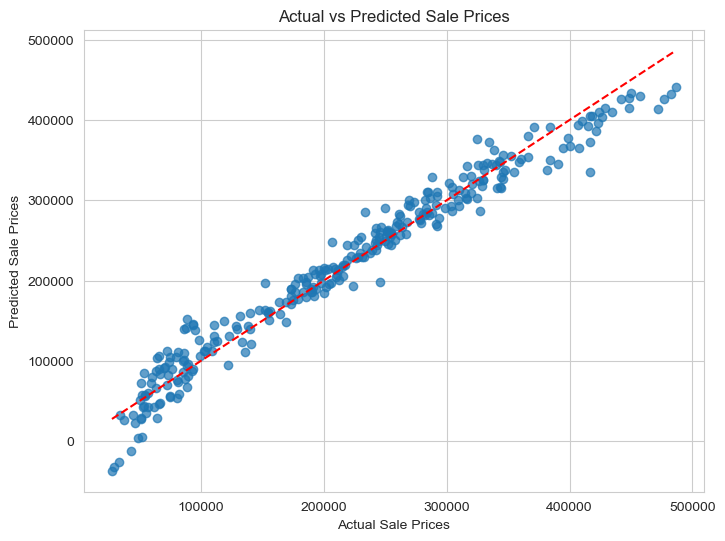

In [98]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    lr_preds,
    alpha=0.7
)

plt.xlabel("Actual Sale Prices")

plt.ylabel("Predicted Sale Prices")

plt.title("Actual vs Predicted Sale Prices")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

### Observation

The predictions closely follow the diagonal reference line, indicating strong agreement between actual and predicted house prices.

Most prediction errors appear relatively small, suggesting that the model generalizes well to unseen data.

## Residual Analysis

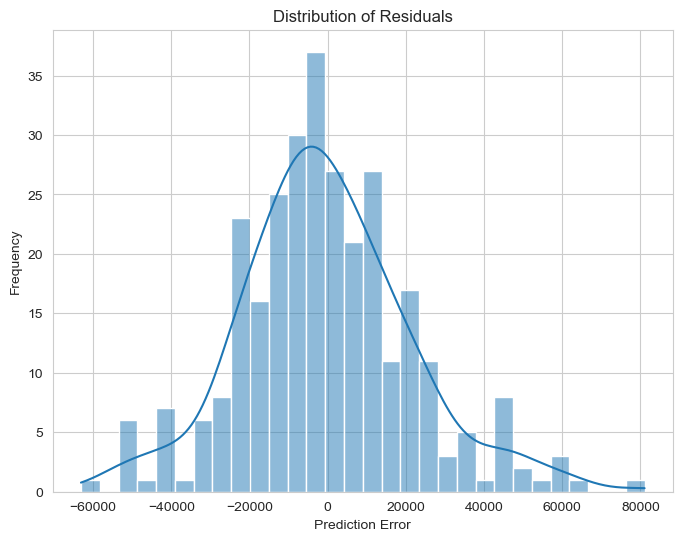

In [99]:
# Residuals
residuals = y_test - lr_preds

plt.figure(figsize=(8, 6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Distribution of Residuals")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

### Observation

The residual distribution appears reasonably centered around zero, suggesting that the model does not exhibit substantial systematic bias in prediction.

# Sample Predictions

To demonstrate real world usability, the trained model was used to predict house sale prices for sample properties from the test dataset.

In [100]:
# Creating comparison table

prediction_results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': lr_preds
})

# Calculate error
prediction_results['Difference'] = (
    prediction_results['Actual Price']
    - prediction_results['Predicted Price']
)

# Show first 10 predictions
prediction_results.head(10)

,Actual Price,Predicted Price,Difference
0,37360,26838.769575,10521.230425
1,408034,364811.273238,43222.726762
2,191761,213151.334102,-21390.334102
3,250823,255413.515233,-4590.515233
4,52229,57500.695141,-5271.695141
5,214877,216774.352265,-1897.352265
6,173455,181200.505279,-7745.505279
7,288124,284814.078663,3309.921337
8,152657,196889.750975,-44232.750975
9,384440,390890.782727,-6450.782727


### Prediction Analysis

The prediction results demonstrate that the Linear Regression model performs effectively across a wide range of house prices.

For many observations, the predicted prices are relatively close to the actual sale prices, indicating strong model accuracy and good generalization performance.

Some properties exhibit larger prediction differences, which may result from:
- unobserved property characteristics
- market variability
- nonlinear relationships not fully captured by Linear Regression

Overall, the prediction table confirms that the model is capable of generating reliable house price estimates using the available features.

In [101]:
# Percentage error
prediction_results['Percentage Error (%)'] = (
    abs(prediction_results['Difference'])
    / prediction_results['Actual Price']
) * 100

prediction_results.head(10)

,Actual Price,Predicted Price,Difference,Percentage Error (%)
0,37360,26838.769575,10521.230425,28.161752
1,408034,364811.273238,43222.726762,10.592923
2,191761,213151.334102,-21390.334102,11.154684
3,250823,255413.515233,-4590.515233,1.830181
4,52229,57500.695141,-5271.695141,10.093425
5,214877,216774.352265,-1897.352265,0.882995
6,173455,181200.505279,-7745.505279,4.465426
7,288124,284814.078663,3309.921337,1.148784
8,152657,196889.750975,-44232.750975,28.975252
9,384440,390890.782727,-6450.782727,1.677969


### Prediction Accuracy Evaluation

The percentage error analysis indicates that the model achieves strong prediction accuracy for many properties.

Several predictions exhibit very low percentage errors, demonstrating that the model closely estimates actual house prices for a large portion of the dataset.

A smaller number of properties show higher percentage errors, which may be influenced by:
- unusual property characteristics
- market fluctuations
- hidden variables not included in the dataset

Overall, the results suggest that the model generalizes effectively and provides reliable price predictions across different property categories.

# Business Insights

## Key Insights from the Analysis

### 1. Property Area Strongly Influences Sale Price
The analysis revealed a positive relationship between property area and sale price. Larger properties generally command higher market values.

### 2. Location Plays an Important Role
Property prices varied across different cities, suggesting that location significantly impacts housing valuation.

### 3. House Type Affects Pricing
Different house categories demonstrated varying price distributions, indicating that property structure influences market demand and pricing.

### 4. Most Predictions Were Highly Accurate
The machine learning model produced relatively low prediction errors for many properties, demonstrating strong predictive capability.

### 5. Some Properties Are More Difficult to Predict
A smaller number of houses exhibited larger prediction errors, possibly due to hidden variables not included in the dataset such as:
- neighborhood quality
- property age
- renovation status
- nearby infrastructure

# Business Recommendations

## Recommendations

### 1. Use Predictive Analytics for Pricing
Real estate agencies can use machine learning models to estimate competitive property prices more efficiently.

### 2. Prioritize High-Value Property Features
Features such as property area and location demonstrated strong influence on sale price and should be emphasized in property valuation strategies.

### 3. Improve Data Collection
Collecting additional property features may improve model accuracy further. Potential variables include:
- property age
- school proximity
- crime rates
- parking availability
- renovation history

### 4. Support Investment Decision Making
The predictive model may assist investors in identifying potentially undervalued or overpriced properties.

### 5. Reduce Pricing Bias
Machine learning can help standardize pricing decisions and reduce subjective valuation inconsistencies.

# Executive Summary

This project successfully developed a machine learning solution for predicting house sale prices using housing market data.

The project workflow included:
- data cleaning
- preprocessing
- exploratory data analysis
- feature engineering
- predictive modeling
- performance evaluation
- business insight generation

The Linear Regression model achieved strong predictive performance with:
- MAE: 16,775.85
- RMSE: 22,110.57
- R² Score: 0.9629

The results indicate that the model explains approximately 96% of the variation in house sale prices, demonstrating excellent predictive capability.

This project highlights practical applications of data science and machine learning in real estate analytics and business decision-making.